In [1]:
from ema_forecast_control.utils import path_utils, model_catalogue

SAVE = False

project_name = f'v3_MRT3_every_day_best_latest_all'

labels = ['EMA_mood','EMA_disappointed','EMA_scared','EMA_worry',
    'EMA_down','EMA_sad','EMA_confidence','EMA_stress','EMA_lonely',
    'EMA_energetic','EMA_concentration','EMA_resilience','EMA_tired',
    'EMA_satisfied', 'EMA_relaxed']
input_labels = [f'interactive{i}' for i in range(1, 9)]


models = model_catalogue.ModelCatalogue(project_name, force_new_catalogue=True)
test_data_dir = path_utils.join_base_path('data/AI4U_sample3')

Calculate proximal effects

In [2]:
from tqdm import tqdm
import pandas as pd

from ema_forecast_control.utils import network_utils

effects = []
emi_occurrences = []
participants = []

data_files = path_utils.get_data_files(test_data_dir)
for p, df in tqdm(path_utils.zip_participants_data(test_data_dir), 
                  total=len(data_files), desc=f'Calculating proximal effects'):    
    participant_effects, participant_emi_occurrences = network_utils.get_proximal_effects(df, labels, input_labels, binned_policy='ignore')
    participants.append(p)
    effects.append(participant_effects)
    emi_occurrences.append(participant_emi_occurrences)

effects = pd.concat(effects, axis=1).T; emi_occurrences = pd.concat(emi_occurrences, axis=1).T
effects['Participant'] = participants; emi_occurrences['Participant'] = participants
effects = effects.set_index('Participant'); emi_occurrences = emi_occurrences.set_index('Participant')

Calculating proximal effects: 100%|██████████| 59/59 [00:00<00:00, 117.30it/s]


Calculate CIRs with latest model ensembles

In [3]:
import torch as tc

from ema_forecast_control.plrnn.plrnn_model import PLRNN
from ema_forecast_control.utils import model_catalogue

plrnn_emi_cir = []
errors_loading_model = 0
ModelClass = PLRNN

data_files = path_utils.get_data_files(test_data_dir)
for p, df in tqdm(path_utils.zip_participants_data(test_data_dir), total=len(data_files), desc=f'Calculating Impulse Responses'):            
    model_dirs = models.get_latest_model_dirs(p, 1000)
    participant_cir = []
    for model_dir in model_dirs:
        model_cir = []
        args = path_utils.load_args(model_dir)
        model = ModelClass(args)
        model.init_from_model_path(model_dir)
        try:
            Gamma = tc.load(path_utils.join_base_path(model_dir, 'empirical_covariance.pt'))
        except:
            errors_loading_model += 1
            continue
        dim_x, dim_s = args['dim_x'], args['dim_s']
        
        for x0 in [tc.tensor(df[labels].to_numpy()).float(),
                    tc.tensor(df.loc[df[labels].sum(axis=1)>0, labels].to_numpy()).float(),
                    tc.cat((tc.eye(dim_x).float(), tc.zeros(dim_x).float().unsqueeze(0)), 0)]:
            cir = tc.zeros(dim_s)
            for i in range(dim_s):
                perturbation = tc.zeros(dim_s).float()
                perturbation[i] = 1
                cir[i] = tc.nanmean(network_utils.impulse_response(model, perturbation, 1, cumulative=True, relative=True, x0=x0, Gamma=Gamma))
            model_cir.append(cir.detach().numpy())
        model_cir = pd.DataFrame(model_cir, columns=input_labels, index=['all', 'emi', 'unit'])
        model_cir['timestep'] = int(float(args['train_on_data_until_timestep']))
        model_cir.index.name = 'x0'
        participant_cir.append(model_cir)
    if len(participant_cir) == 0:
        continue
    participant_cir_df = pd.concat(participant_cir, axis=0)            
    participant_cir_df = pd.concat([participant_cir_df.groupby('x0').mean(numeric_only=True),            # Mean over all models
                                    participant_cir_df.loc[participant_cir_df['timestep']==participant_cir_df['timestep'].max()]],  # just the last model
                                    axis=0, keys=['all', 'last'], names=['model'])
    participant_cir_df['participant'] = p
    participant_cir_df = participant_cir_df.set_index(['participant'], append=True)[input_labels]
    plrnn_emi_cir.append(participant_cir_df)
plrnn_emi_cir = pd.concat(plrnn_emi_cir, axis=0)

if errors_loading_model > 0:
    print(f"Warning: {errors_loading_model} errors loading Gamma and B.")

Calculating Impulse Responses: 100%|██████████| 59/59 [00:02<00:00, 25.48it/s]


Plot rank correlations histogram

In [ ]:
plrnn_emi_cir

interactive1  interactive2  interactive3  \
model x0   participant                                             
all   all  201              0.043999     -0.026510      0.016470   
      emi  201              0.043999     -0.026510      0.016470   
      unit 201              0.043999     -0.026510      0.016470   
last  all  201              0.043999     -0.026510      0.016470   
      emi  201              0.043999     -0.026510      0.016470   
...                              ...           ...           ...   
all   emi  301             -0.026976     -0.089546     -0.356231   
      unit 301             -0.026976     -0.089545     -0.356230   
last  all  301             -0.026976     -0.089546     -0.356231   
      emi  301             -0.026976     -0.089546     -0.356231   
      unit 301             -0.026976     -0.089545     -0.356230   

                        interactive4  interactive5  interactive6  \
model x0   participant                                             
all   all  201              0.017876     -0.010684     -0.012270   
      emi  201              0.017876     -0.010684     -0.012270   
      unit 201              0.017876     -0.010684     -0.012270   
last  all  201              0.017876     -0.010684     -0.012270   
      emi  201              0.017876     -0.010684     -0.012270   
...                              ...           ...           ...   
all   emi  301             -0.015548      0.085519     -0.045389   
      unit 301             -0.015548      0.085519     -0.045389   
last  all  301             -0.015548      0.085519     -0.045389   
      emi  301             -0.015548      0.085519     -0.045389   
      unit 301             -0.015548      0.085519     -0.045389   

                        interactive7  interactive8  
model x0   participant                              
all   all  201              0.113599     -0.000280  
      emi  201              0.113599     -0.000280  
      unit 201              0.113599     -0.000280  
last  all  201              0.113599     -0.000280  
      emi  201              0.113599     -0.000280  
...                              ...           ...  
all   emi  301             -0.090599      0.036175  
      unit 301             -0.090599      0.036175  
last  all  301             -0.090599      0.036175  
      emi  301             -0.090599      0.036175  
      unit 301             -0.090599      0.036175  

[354 rows x 8 columns]

In [4]:
import matplotlib.pyplot as plt

from ema_forecast_control.utils.weighted_correlation import weight_corr_for_dataframes, meta_spearman, participant_bootstrap_pooled_corr, hierarchical_bootstrap_pooled_corr, weighted_spearman

select_model = 'all'
select_x0 = 'all'
            
plrnn_emi_rank = plrnn_emi_cir.loc[(select_model, select_x0)]
effects_rank = effects.loc[plrnn_emi_rank.index]
correlations = weight_corr_for_dataframes(plrnn_emi_rank, effects_rank, emi_occurrences.loc[plrnn_emi_rank.index], method='spearman', axis=1, B=1, alternative='greater', 
                                            p_method='permutation', ci_type='percentile', clip_ci=True)
joint_correlations = correlations['statistic']

participant_order = correlations.sort_values(by='statistic').dropna().index
dropped = correlations.loc[correlations['statistic'].isna()].index.to_list()

if len(dropped) > 0:
    print(f'Dropped {dropped}')

print(f'Percent correlations >0.5: {100*(correlations["statistic"]>0.5).mean()}')
print(f'                     >0.3: {100*((correlations["statistic"]>0.3) & (correlations["statistic"]<=0.5)).mean()}')
print(f'                     >0.1: {100*((correlations["statistic"]>0.1) & (correlations["statistic"]<=0.3)).mean()}')

overall_effect = meta_spearman(correlations['statistic'].dropna(), None)
overall_effect2 = participant_bootstrap_pooled_corr(correlations['statistic'].dropna())
overall_effect3 = hierarchical_bootstrap_pooled_corr(plrnn_emi_rank.to_numpy(), effects_rank.to_numpy(), emi_occurrences.loc[plrnn_emi_rank.index].to_numpy(), weighted_spearman, B_outer=10000, seed=1)

print(f'Group-wise correlation: {overall_effect["effect"]:.3f}, 95% CI [{overall_effect["ci_lower"]:.3f}, {overall_effect["ci_upper"]:.3f}], p={overall_effect["p"]:.3f}')
print(f'Group-wise correlation 2: {overall_effect2["pooled_effect"]:.3f}, 95% CI [{overall_effect2["ci_lower"]:.3f}, {overall_effect2["ci_upper"]:.3f}], p={overall_effect2["p_value"]:.3f}')
print(f'Group-wise correlation 3: {overall_effect3["pooled_effect"]:.3f}, 95% CI [{overall_effect3["ci_lower"]:.3f}, {overall_effect3["ci_upper"]:.3f}], p={overall_effect3["p_value"]:.3f}')

# print(f'Overall percent >0.5: {100*(joint_correlations.stack()>0.5).mean()}')
# print(f'Overall percent >0.3: {100*((joint_correlations.stack()>0.3) & (joint_correlations.stack()<=0.5)).mean()}')
# print(f'Overall percent >0.1: {100*((joint_correlations.stack()>0.1) & (joint_correlations.stack()<=0.3)).mean()}')

/tmp/ipykernel_84480/2525076881.py:8: PerformanceWarning: indexing past lexsort depth may impact performance.
  plrnn_emi_rank = plrnn_emi_cir.loc[(select_model, select_x0)]


Percent correlations >0.5: 33.89830508474576
                     >0.3: 27.11864406779661
                     >0.1: 6.779661016949152


Hierarchical Bootstrap: 100%|██████████| 10000/10000 [02:07<00:00, 78.61it/s]

Group-wise correlation: 0.292, 95% CI [0.185, 0.393], p=0.000
Group-wise correlation 2: 0.292, 95% CI [0.153, 0.418], p=0.000
Group-wise correlation 3: 0.292, 95% CI [0.104, 0.705], p=0.010


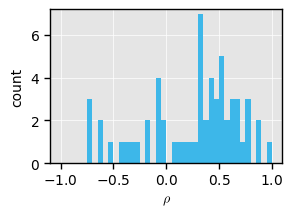

In [5]:
import numpy as np

from ema_forecast_control.plotting.plotting_styles import PaperStyle, adjust_ylim

with PaperStyle():
    fig, ax = plt.subplots(1, 1, figsize=(3,2))
    joint_correlations.plot(ax=ax, kind='hist', ylabel='count', xlabel=r'$\rho$', bins=np.arange(-1, 1.05, 0.05), stacked=True)
    adjust_ylim(ax, top=0.03, bottom=0.0)
    plt.show()

Analyze the change in total rank correlation when subjects with few samples are iteratively excluded

In [23]:
effects.index.names

FrozenList(['Participant'])

/tmp/ipykernel_84480/1626700896.py:16: PerformanceWarning: indexing past lexsort depth may impact performance.
  plrnn_emi_rank = plrnn_emi_cir.loc[(select_model, select_x0)]


ANOVA results:
               df     sum_sq   mean_sq         F    PR(>F)
C(min_EMI)    9.0   2.272570  0.252508  1.571491  0.123086
Residual    297.0  47.722065  0.160680       NaN       NaN


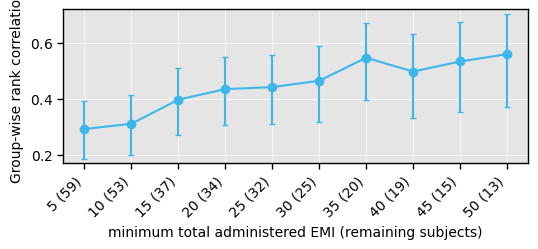

In [6]:
import sys
sys.path.append('..')
import torch as tc
import statsmodels.api as sm
from statsmodels.formula.api import ols

from ema_forecast_control.plotting.plotting_styles import colors

select_model = 'all'
select_x0 = 'all'

with PaperStyle():

    fig, ax = plt.subplots(1, 1, figsize=(6,2))    
            
    plrnn_emi_rank = plrnn_emi_cir.loc[(select_model, select_x0)]
    total_emis = emi_occurrences.sum(axis=1).loc[plrnn_emi_rank.index]
    effects_rank = effects.loc[plrnn_emi_rank.index]
    emi_occurrences_loc = emi_occurrences.loc[plrnn_emi_rank.index]
    
    group_wise_effects = []
    n_participants_remaining = []

    bins = np.arange(5, 51, 5)
    correlations_over_bins = []
    
    for i in bins:
        correlations = weight_corr_for_dataframes(plrnn_emi_rank.loc[total_emis>=i], 
                                                    effects_rank.loc[total_emis>=i], 
                                                    emi_occurrences_loc.loc[total_emis>=i], method='spearman', axis=1, B=2, alternative='greater', 
                                                p_method='permutation', ci_type='percentile')
        correlations_over_bins.append(correlations['statistic'].dropna())
        overall_effect = meta_spearman(correlations['statistic'].dropna(), None)
        group_wise_effects.append(overall_effect)
        n_participants_remaining.append(len(correlations.dropna()))

    group_wise_effects = pd.DataFrame(group_wise_effects)
    group_wise_effects.plot(ax=ax, y='effect', yerr=[group_wise_effects['effect']-group_wise_effects['ci_lower'], group_wise_effects['ci_upper']-group_wise_effects['effect']], 
                            marker='o', legend=False)
    ax.set_xticks(range(len(bins)), [f'{b} ({n})' for b, n in zip(bins, n_participants_remaining)], rotation=45, ha='right')
    ax.set(xlabel='minimum total administered EMI (remaining subjects)', ylabel='Group-wise rank correlation')
    adjust_ylim(ax, top=0.03, bottom=0.03)

    correlations_over_bins_molten = pd.concat(correlations_over_bins, axis=1, keys=bins, names='min_EMI').melt().dropna().astype(float)
    model = ols('value ~ C(min_EMI)', data=correlations_over_bins_molten).fit()
    anova_table = sm.stats.anova_lm(model, typ=1)
    print(f'ANOVA results:')
    print(anova_table)
        
    plt.show()

Plot the permutation of ranks

/tmp/ipykernel_84480/1528076359.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  plrnn_emi_rank = plrnn_emi_cir.loc[(choose_model, choose_x0)].rank(1)


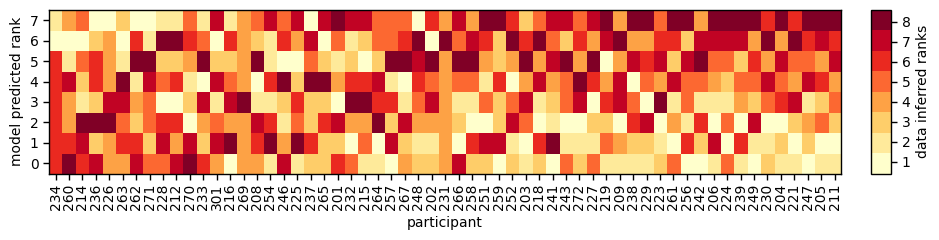

In [10]:
from ema_forecast_control.plotting import discretized_colormap, subplots_with_colorbar

choose_model = 'all'
choose_x0 = 'all'

with PaperStyle(settings={'axes.grid':False}):
    L = len(input_labels)
    cmap = discretized_colormap('YlOrRd', L)
    plrnn_emi_rank = plrnn_emi_cir.loc[(choose_model, choose_x0)].rank(1)
    effects_rank = effects.rank(1)
    correlations = plrnn_emi_rank.corrwith(effects_rank, axis=1, method='spearman')
    participant_order = correlations.sort_values().dropna().index
    participant_order = participant_order.drop([231, 269], errors='ignore')
    reordered_ranks = np.zeros((len(participant_order), L))
    for j, p in enumerate(participant_order):
        reordered_ranks[j] = effects_rank.loc[p].loc[plrnn_emi_rank.loc[p].sort_values().index].to_numpy()

    fig, ax = subplots_with_colorbar(reordered_ranks.T, nrows=1, cmap=cmap, aspect='auto', axes_pad=1.5, cbar_size='2.5%',
                                    figsize=(9.5,2.5), cbar_ticks=np.linspace(1.5, L-0.5, L), cbar_ticklabels=range(1,L+1),
                                    image_grid_aspect=False)

    ax[0].set_xlabel('participant')
    ax[0].set_ylabel('model predicted rank')
    ax[0].set_xticks(range(len(participant_order)), labels=participant_order, rotation=90)
    ax[0].set_yticks(range(L), labels=np.arange(L))
    ax[0].cax.set_ylabel('data inferred ranks')

    plt.tight_layout()
    plt.show()